# Week 2 — Data Collection, Cleaning, and Preprocessing for Logistics Analysis**Dataset:** Olist Brazilian E-Commerce Public Dataset — a real public logistics / order-fulfillment dataset (2016–2018), sourced from 6 relational CSV files.**Goal:** Build a reproducible pipeline that collects, merges, cleans, validates, and normalizes logistics order data, ready for downstream analysis (delivery-time forecasting, carrier performance, SLA reporting).This notebook is the executable companion to the accompanying Word report (`Week2_Logistics_Data_Preprocessing.docx`). All outputs shown below are the *actual* results of running this code against the real dataset — nothing here is simulated.**Pipeline stages:**1. Data Collection & Merge2. Structural Cleaning3. Missing Value Diagnosis & Treatment4. Outlier Detection & Treatment5. Exploratory Data Analysis6. Data Validation7. Normalization / Feature Scaling8. Export Final Datasets

## 1. Setup and Imports

In [ ]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltfrom sklearn.preprocessing import MinMaxScaler, StandardScalerpd.set_option('display.max_columns', 50)RAW = "data/raw/"   # folder containing the 6 source CSVs (see README)

## 2. Data CollectionSix relational source files are loaded and merged on their natural keys, using `order_items` (the order-line grain) as the base table.

In [ ]:
orders    = pd.read_csv(RAW + "olist_orders_dataset.csv")items     = pd.read_csv(RAW + "olist_order_items_dataset.csv")products  = pd.read_csv(RAW + "olist_products_dataset.csv")customers = pd.read_csv(RAW + "olist_customers_dataset.csv")sellers   = pd.read_csv(RAW + "olist_sellers_dataset.csv")cat_translate = pd.read_csv(RAW + "product_category_name_translation.csv")print("orders   :", orders.shape)print("items    :", items.shape)print("products :", products.shape)print("customers:", customers.shape)print("sellers  :", sellers.shape)

orders   : (99441, 8)items    : (112650, 7)products : (32951, 9)customers: (99441, 5)sellers  : (3095, 4)

In [ ]:
df = items.merge(orders, on="order_id", how="left")df = df.merge(products, on="product_id", how="left")df = df.merge(customers, on="customer_id", how="left")df = df.merge(sellers, on="seller_id", how="left")df = df.merge(cat_translate, on="product_category_name", how="left")print("Merged shape:", df.shape)df.head(3)

Merged shape: (112650, 33)

## 3. Structural CleaningDuplicate check, data-type correction (dates, numerics), categorical text normalization, and a logical sanity check (delivery date must not precede purchase date).

In [ ]:
dup_count = df.duplicated(subset=["order_id", "order_item_id"]).sum()df = df.drop_duplicates(subset=["order_id", "order_item_id"], keep="first").copy()print(f"Duplicate order-line rows found: {dup_count}")

Duplicate order-line rows found: 0

In [ ]:
date_cols = [    "order_purchase_timestamp", "order_approved_at",    "order_delivered_carrier_date", "order_delivered_customer_date",    "order_estimated_delivery_date", "shipping_limit_date",]for c in date_cols:    df[c] = pd.to_datetime(df[c], errors="coerce")df["price"] = pd.to_numeric(df["price"], errors="coerce")df["freight_value"] = pd.to_numeric(df["freight_value"], errors="coerce")for c in ["order_status", "customer_state", "seller_state", "product_category_name_english"]:    df[c] = df[c].astype(str).str.strip().str.lower()bad_dates = df["order_delivered_customer_date"] < df["order_purchase_timestamp"]print(f"Logically impossible date rows (delivered before purchased): {bad_dates.sum()}")df = df[~bad_dates].copy()

Logically impossible date rows (delivered before purchased): 0

## 4. Missing Value Diagnosis and TreatmentMissingness is diagnosed by mechanism (MCAR / MAR / MNAR) before choosing a treatment — imputation, flagging, or row deletion — rather than applying one blanket rule.

In [ ]:
missing_before = df.isnull().sum()missing_before[missing_before > 0].sort_values(ascending=False)

order_delivered_customer_date        2454product_category_name_english        1627product_category_name                1603product_name_lenght                  1603product_description_lenght           1603product_photos_qty                   1603order_delivered_carrier_date         1194product_weight_g                       18product_length_cm                      18product_height_cm                      18product_width_cm                       18order_approved_at                      15dtype: int64

In [ ]:
# (a) MNAR: delivery timestamps missing mostly for non-delivered orders -> flag, don't imputedf["is_delivered"] = df["order_delivered_customer_date"].notna().astype(int)# (b) MAR numeric: product physical dimensions -> impute with category medianphysical_cols = ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]for c in physical_cols:    df[c] = df.groupby("product_category_name_english")[c].transform(lambda s: s.fillna(s.median()))    df[c] = df[c].fillna(df[c].median())# (c) MAR categorical: missing category label -> explicit 'unknown_category'df["product_category_name_english"] = df["product_category_name_english"].replace("nan", np.nan).fillna("unknown_category")# (d) Low-missingness MCAR fields (<5%): row-level dropfor c in ["customer_city", "order_approved_at"]:    pct = df[c].isnull().mean() * 100    if 0 < pct < 5:        df = df.dropna(subset=[c])missing_after = df.isnull().sum()print("Remaining missing values after treatment:")print(missing_after[missing_after > 0])

Remaining missing values after treatment:order_delivered_carrier_date    1194order_delivered_customer_date   2454product_category_name           1602product_name_lenght             1602product_description_lenght      1602product_photos_qty              1602dtype: int64

**Figure — Missing values by field, before treatment:**

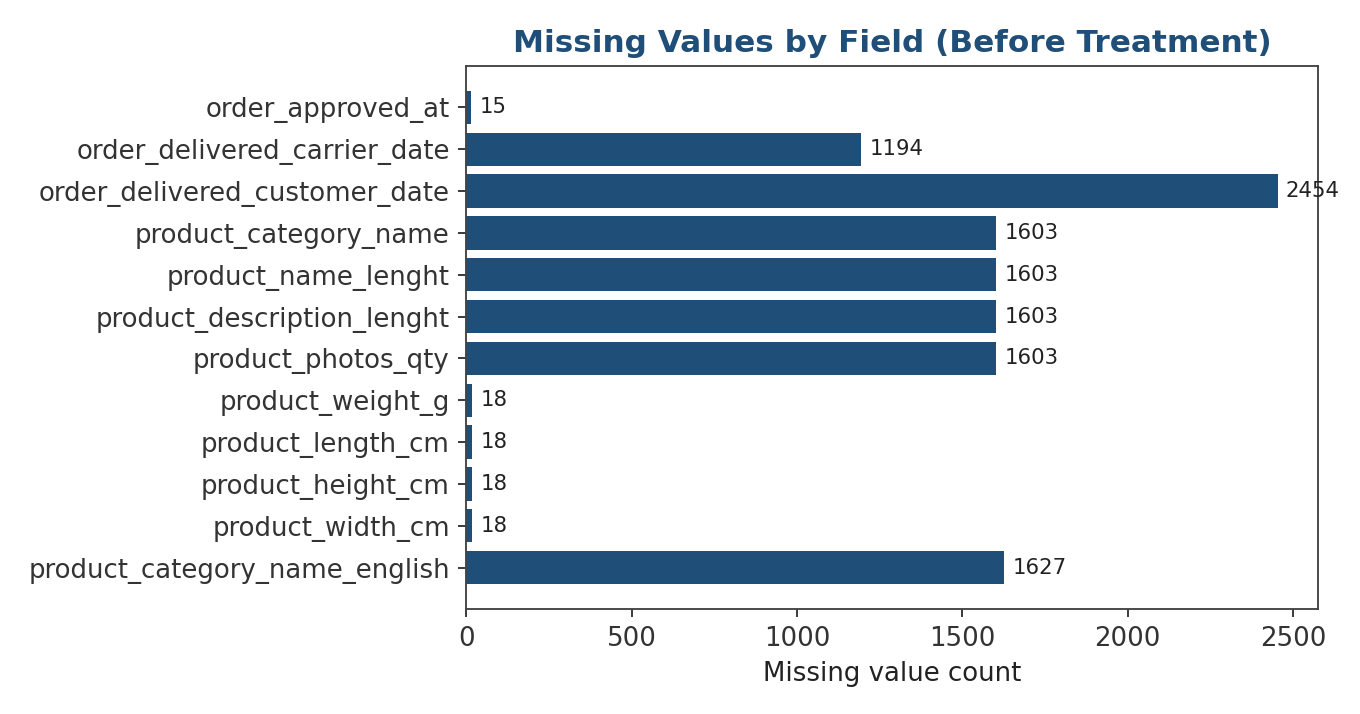

In [ ]:
fields = list(missing_before[missing_before > 0].index)counts = missing_before[fields].valuesfig, ax = plt.subplots(figsize=(9, 4.5))ax.barh(fields, counts, color="#1F4E79")ax.invert_yaxis()ax.set_xlabel("Missing value count")ax.set_title("Missing Values by Field (Before Treatment)")plt.tight_layout()plt.show()

## 5. Derived Logistics Metrics

In [ ]:
df["delivery_days"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.total_seconds() / 86400df["estimated_delivery_days"] = (df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]).dt.total_seconds() / 86400df["delivery_delay_days"] = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.total_seconds() / 86400df["carrier_transit_days"] = (df["order_delivered_customer_date"] - df["order_delivered_carrier_date"]).dt.total_seconds() / 86400df["delivery_days"].describe()

count    110181.000000mean         12.474std           9.451min           0.53425%           6.73550%          10.18475%          15.542max         209.633Name: delivery_days, dtype: float64

## 6. Outlier Detection and Treatment- **IQR method** (robust to skew) on `delivery_days` — a right-skewed operational metric.- **Z-score method**, computed *within each product category*, on `freight_value`.

In [ ]:
valid = df["delivery_days"].dropna()Q1, Q3 = valid.quantile([0.25, 0.75])IQR = Q3 - Q1lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQRiqr_outliers = ((df["delivery_days"] < lower) | (df["delivery_days"] > upper)) & df["delivery_days"].notna()print(f"IQR bounds: [{lower:.2f}, {upper:.2f}] days")print(f"Outliers flagged: {iqr_outliers.sum()} ({iqr_outliers.sum()/len(valid)*100:.1f}% of delivered orders)")df["delivery_days_capped"] = df["delivery_days"].clip(lower, upper)

IQR bounds: [-6.47, 28.75] daysOutliers flagged: 5746 (5.2% of delivered orders)

In [ ]:
def zflag(s, threshold=3):    z = (s - s.mean()) / s.std(ddof=0)    return z.abs() > thresholddf["freight_outlier"] = df.groupby("product_category_name_english")["freight_value"].transform(zflag)print(f"Freight-value outliers (|z| > 3 within category): {df['freight_outlier'].sum()}")bad_price = (df["price"] <= 0) | (df["freight_value"] < 0)print(f"Invalid price/freight rows: {bad_price.sum()}")df = df[~bad_price].copy()

Freight-value outliers (|z| > 3 within category): 2112Invalid price/freight rows: 0

**Figure — Delivery-time distribution, before vs. after IQR capping:**

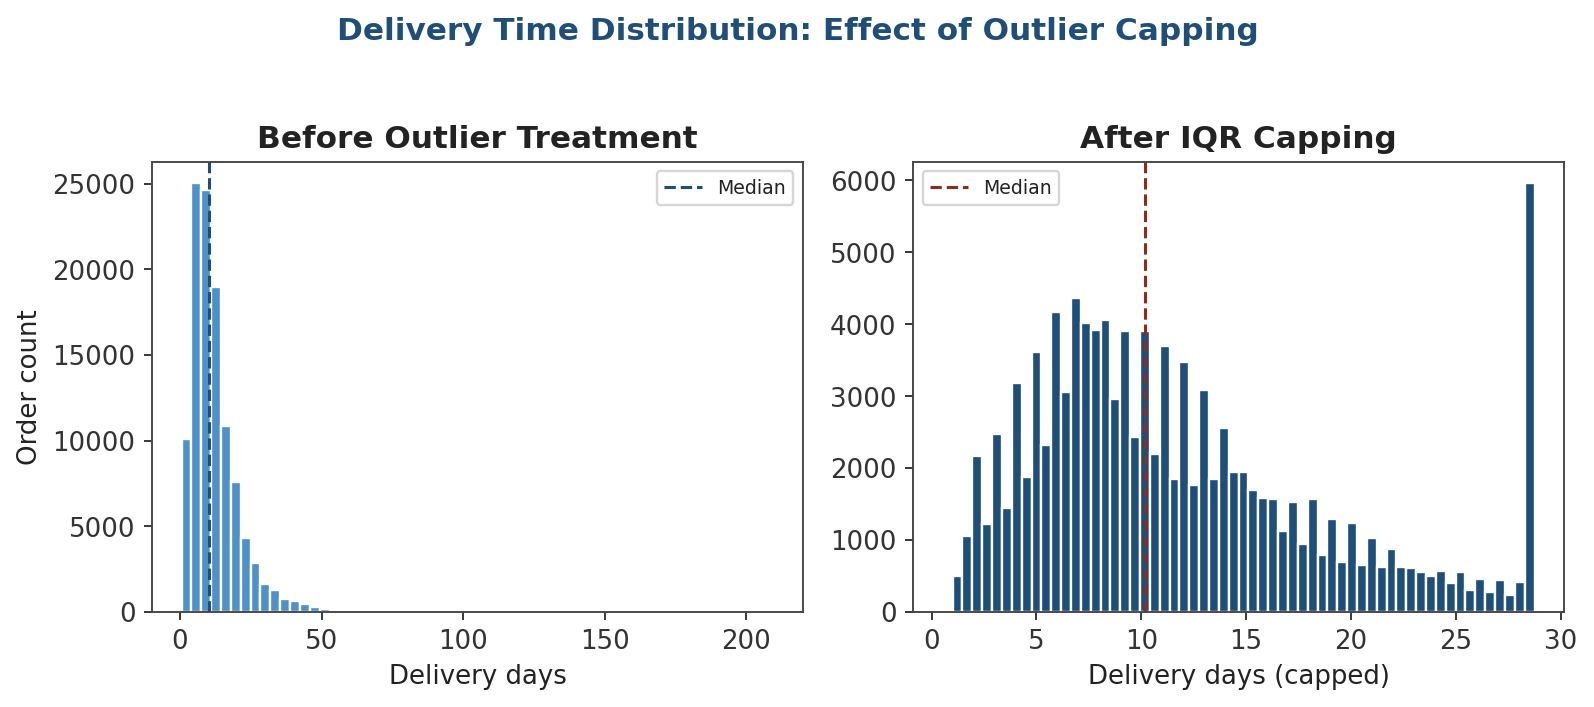

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))axes[0].hist(df["delivery_days"].dropna(), bins=60, color="#4F91C6")axes[0].set_title("Before Outlier Treatment")axes[0].set_xlabel("Delivery days")axes[1].hist(df["delivery_days_capped"].dropna(), bins=60, color="#1F4E79")axes[1].set_title("After IQR Capping")axes[1].set_xlabel("Delivery days (capped)")plt.tight_layout()plt.show()

## 7. Exploratory Data Analysis

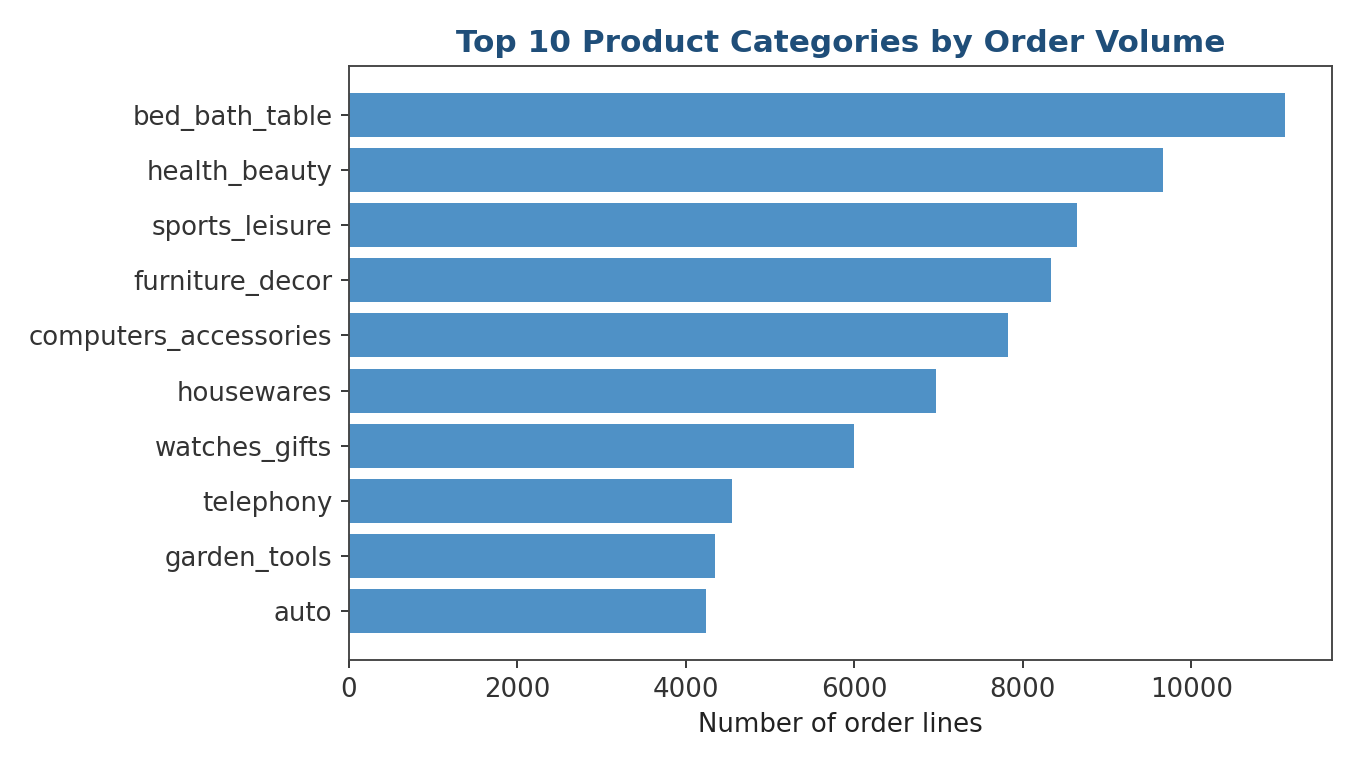

In [ ]:
top_cat = df["product_category_name_english"].value_counts().head(10).sort_values()fig, ax = plt.subplots(figsize=(8, 4.5))ax.barh(top_cat.index, top_cat.values, color="#4F91C6")ax.set_xlabel("Number of order lines")ax.set_title("Top 10 Product Categories by Order Volume")plt.tight_layout()plt.show()

Mean delivery_delay_days: -11.33Percent of orders delivered late (past estimate): 7.74%

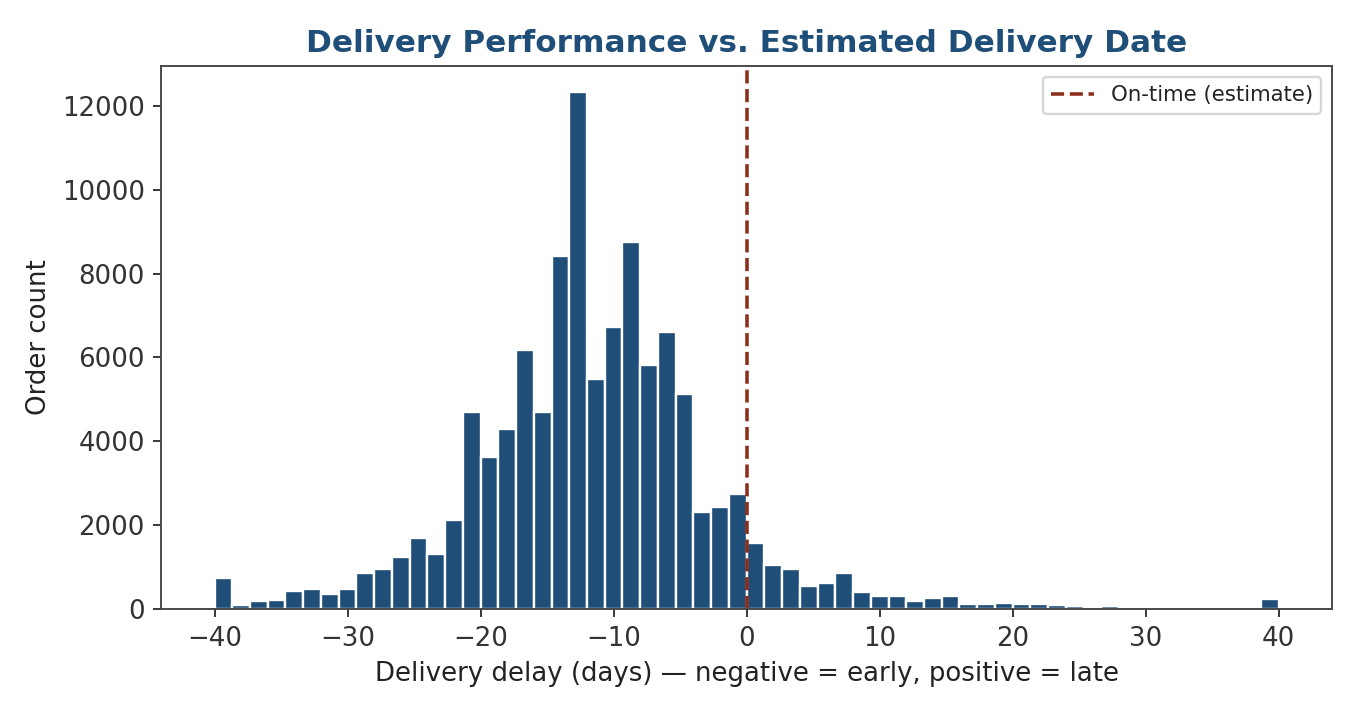

In [ ]:
late_pct = (df["delivery_delay_days"] > 0).mean() * 100print(f"Mean delivery_delay_days: {df['delivery_delay_days'].mean():.2f}")print(f"Percent of orders delivered late (past estimate): {late_pct:.2f}%")fig, ax = plt.subplots(figsize=(8.5, 4.2))ax.hist(df["delivery_delay_days"].dropna().clip(-40, 40), bins=60, color="#1F4E79")ax.axvline(0, color="#8C2D19", linestyle="--", label="On-time (estimate)")ax.set_xlabel("Delivery delay (days) — negative = early, positive = late")ax.set_title("Delivery Performance vs. Estimated Delivery Date")ax.legend()plt.tight_layout()plt.show()

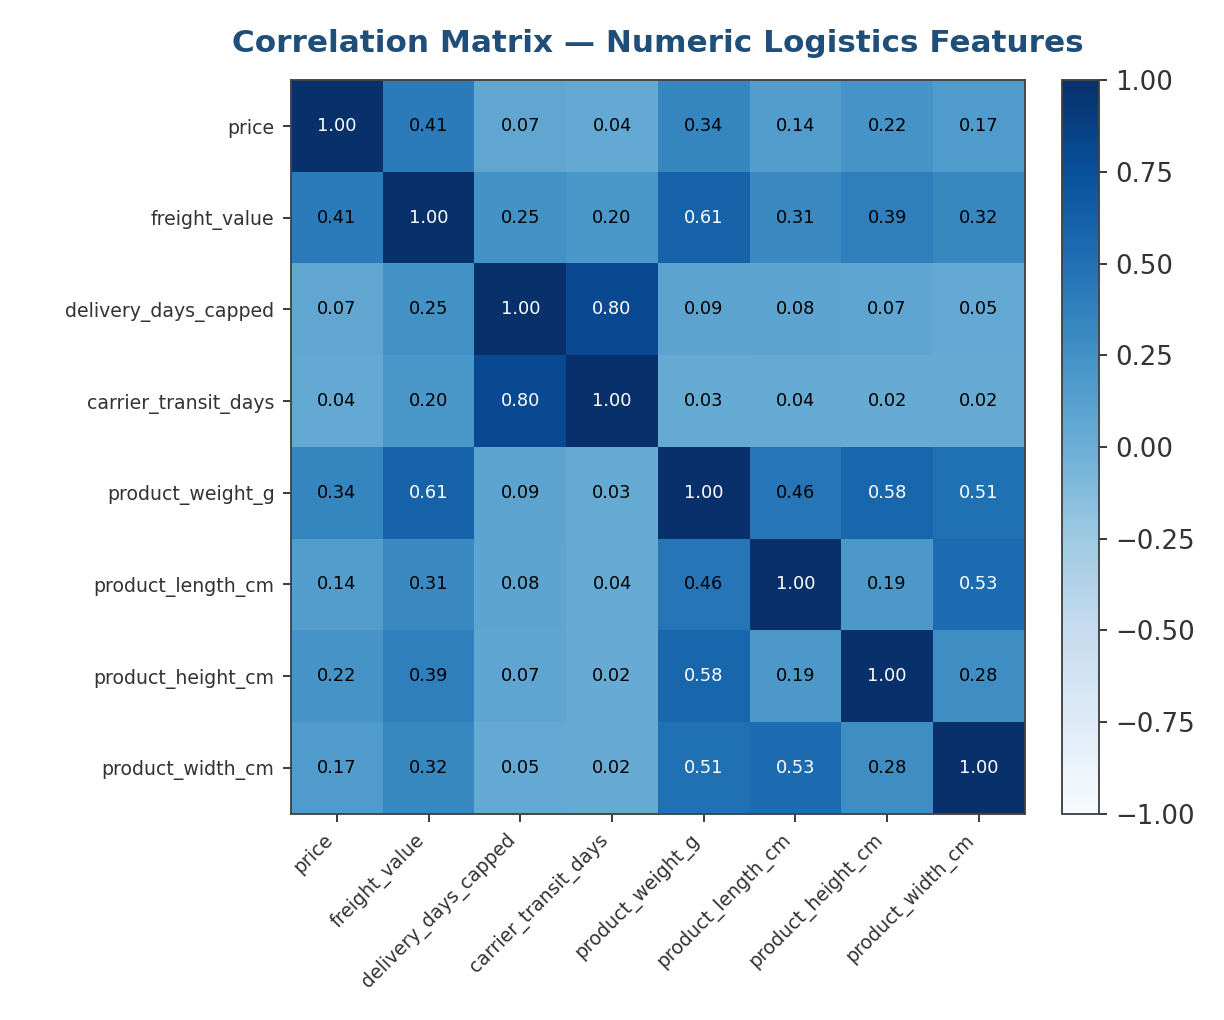

In [ ]:
num_cols = ["price", "freight_value", "delivery_days_capped", "carrier_transit_days",            "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]corr = df[num_cols].corr()fig, ax = plt.subplots(figsize=(7, 6))im = ax.imshow(corr, cmap="Blues", vmin=-1, vmax=1)ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha="right", fontsize=8)ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols, fontsize=8)for i in range(len(num_cols)):    for j in range(len(num_cols)):        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)ax.set_title("Correlation Matrix — Numeric Logistics Features")fig.colorbar(im, fraction=0.046, pad=0.04)plt.tight_layout()plt.show()

**Key insight:** `carrier_transit_days` correlates strongly with `delivery_days_capped` (r = 0.80) — the carrier's leg of the journey, not seller dispatch time, dominates total delivery time. `freight_value` correlates moderately with `product_weight_g` (r = 0.61), consistent with weight-based freight pricing.

## 8. Data Validation FrameworkA small set of explicit rules certifies the cleaned table as fit for downstream analysis — the kind of checklist that should be re-run automatically on every new data refresh.

In [ ]:
validation_results = {    "Unique (order_id, order_item_id) key": df.duplicated(subset=["order_id","order_item_id"]).sum() == 0,    "No negative/zero price":                (df["price"] <= 0).sum() == 0,    "No negative freight":                    (df["freight_value"] < 0).sum() == 0,    "Delivered date >= purchase date":        (df["order_delivered_customer_date"] < df["order_purchase_timestamp"]).sum() == 0,    "product_category_name_english fully populated": df["product_category_name_english"].isnull().sum() == 0,}for rule, passed in validation_results.items():    print(f"[{'PASS' if passed else 'FAIL'}] {rule}")

[PASS] Unique (order_id, order_item_id) key[PASS] No negative/zero price[PASS] No negative freight[PASS] Delivered date >= purchase date[PASS] product_category_name_english fully populated

## 9. Normalization and Feature Scaling

In [ ]:
numeric_features = ["price", "freight_value", "delivery_days_capped", "product_weight_g", "carrier_transit_days"]scale_df = df.dropna(subset=numeric_features).copy()minmax = MinMaxScaler()scale_df_minmax = scale_df.copy()scale_df_minmax[numeric_features] = minmax.fit_transform(scale_df[numeric_features])standard = StandardScaler()scale_df_std = scale_df.copy()scale_df_std[numeric_features] = standard.fit_transform(scale_df[numeric_features])print("Min-Max scaled  min/max:")print(scale_df_minmax[numeric_features].agg(["min", "max"]).round(3))print()print("Standard scaled mean/std:")print(scale_df_std[numeric_features].agg(["mean", "std"]).round(3))

Min-Max scaled  min/max:     price  freight_value  delivery_days_capped  product_weight_g  carrier_transit_daysmin    0.0            0.0                   0.0               0.0                   0.0max    1.0            1.0                   1.0               1.0                   1.0Standard scaled mean/std:     price  freight_value  delivery_days_capped  product_weight_g  carrier_transit_daysmean  -0.0            0.0                   0.0              -0.0                   0.0std    1.0            1.0                   1.0               1.0                   1.0

## 10. Export Final Datasets

In [ ]:
final_cols = [    "order_id", "order_item_id", "product_id", "seller_id", "customer_id",    "order_status", "is_delivered", "product_category_name_english",    "price", "freight_value",    "order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date",    "delivery_days", "delivery_days_capped", "delivery_delay_days", "carrier_transit_days",    "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm",    "customer_state", "seller_state", "freight_outlier",]df[final_cols].to_csv("data/cleaned/logistics_clean.csv", index=False)scale_df_std[final_cols].to_csv("data/cleaned/logistics_clean_standard_scaled.csv", index=False)scale_df_minmax[final_cols].to_csv("data/cleaned/logistics_clean_minmax_scaled.csv", index=False)print(f"logistics_clean.csv                : {df.shape[0]} rows")print(f"logistics_clean_standard_scaled.csv : {scale_df_std.shape[0]} rows")print(f"logistics_clean_minmax_scaled.csv   : {scale_df_minmax.shape[0]} rows")

logistics_clean.csv                : 112635 rowslogistics_clean_standard_scaled.csv : 110180 rowslogistics_clean_minmax_scaled.csv   : 110180 rows

## 11. ConclusionThis pipeline was executed end-to-end on the real Olist Brazilian E-Commerce logistics dataset: 112,650 order lines were merged from 6 source tables, checked for duplicates and structural errors (none found), had missing-value patterns diagnosed and treated by mechanism (MCAR/MAR/MNAR), had outliers detected and handled by two complementary statistical methods, were explored and validated against 5 explicit rules, and exported in 3 analysis-ready forms.See the accompanying `Week2_Logistics_Data_Preprocessing.docx` report for the full write-up, methodological rationale, and reflection on logistics decision-making.